# **Model 1 - MobileNetV2**

# Import Libraries

In [ ]:

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import zipfile
import os
import shutil
from google.colab import files

# Import Datasets

In [ ]:
print("📂 Please upload data1.zip and data2.zip")
uploaded = files.upload()

📂 Please upload data1.zip and data2.zip


TypeError: 'NoneType' object is not subscriptable

# Import Datasets Path

In [ ]:
data1_path = "/content/data1.zip"
data2_path = "/content/data2.zip"

# Datasets Extract

In [ ]:
import zipfile
import os
import shutil

temp_extract_path_1 = "/content/temp_extracted_data1"
temp_extract_path_2 = "/content/temp_extracted_data2"

if os.path.exists(temp_extract_path_1):
    shutil.rmtree(temp_extract_path_1)
os.makedirs(temp_extract_path_1, exist_ok=True)

if os.path.exists(temp_extract_path_2):
    shutil.rmtree(temp_extract_path_2)
os.makedirs(temp_extract_path_2, exist_ok=True)

with zipfile.ZipFile(data1_path, 'r') as zip_ref:
    zip_ref.extractall(temp_extract_path_1)

with zipfile.ZipFile(data2_path, 'r') as zip_ref:
    zip_ref.extractall(temp_extract_path_2)

print("Datasets extracted to temporary locations successfully!")

Datasets extracted to temporary locations successfully!


# Consolidate Images

In [ ]:
import os
import shutil

final_data_dir = "/content/consolidated_images"

if os.path.exists(final_data_dir):
    shutil.rmtree(final_data_dir)
os.makedirs(final_data_dir, exist_ok=True)

def consolidate_images(source_base_dir, destination_base_dir):
    for root, dirs, files in os.walk(source_base_dir):

        if any(f.lower().endswith(('.jpg', '.jpeg', '.png')) for f in files):
            class_name = os.path.basename(root)
            dest_class_dir = os.path.join(destination_base_dir, class_name)
            os.makedirs(dest_class_dir, exist_ok=True)

            for img_file in files:
                if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    src_img_path = os.path.join(root, img_file)
                    dest_img_path = os.path.join(dest_class_dir, img_file)

                    if os.path.exists(dest_img_path):
                        base, ext = os.path.splitext(img_file)
                        counter = 1
                        while os.path.exists(os.path.join(dest_class_dir, f"{base}_copy{counter}{ext}")):
                            counter += 1
                        dest_img_path = os.path.join(dest_class_dir, f"{base}_copy{counter}{ext}")
                    shutil.copy(src_img_path, dest_img_path)

consolidate_images(temp_extract_path_1, final_data_dir)
consolidate_images(temp_extract_path_2, final_data_dir)

print(f"All images consolidated into: {final_data_dir}")

data_dir = final_data_dir

if os.path.exists(temp_extract_path_1):
    shutil.rmtree(temp_extract_path_1)
if os.path.exists(temp_extract_path_2):
    shutil.rmtree(temp_extract_path_2)

print("Temporary extraction directories cleaned up.")

All images consolidated into: /content/consolidated_images
Temporary extraction directories cleaned up.


# Image Data Generator

In [ ]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True
)

# Image Split Using Image Generator

In [ ]:
from os import listdir, path, makedirs
import shutil
from sklearn.model_selection import train_test_split

output_dir = "dataset_split"
train_path = path.join(output_dir, "train")
val_path = path.join(output_dir, "validation")
test_path = path.join(output_dir, "test")

if path.exists(output_dir):
    shutil.rmtree(output_dir)
    print(f"Removed existing directory: {output_dir}")

for p_item in [output_dir, train_path, val_path, test_path]:
    makedirs(p_item, exist_ok=True)
    print(f"Created directory: {p_item}")

print(f"Splitting dataset from: {data_dir}")
for class_name in listdir(data_dir):
    class_dir = path.join(data_dir, class_name)

    if not path.isdir(class_dir):
        print(f"Skipping non-directory item in data_dir: {class_name}")
        continue

    images = [path.join(class_dir, img) for img in listdir(class_dir) if img.lower().endswith(('.jpg', '.jpeg', '.png'))]

    if not images:
        print(f"Warning: No images found for class {class_name} in {class_dir}. Skipping split for this class.")
        continue

    train_files, test_val_files = train_test_split(images, test_size=0.3, random_state=42)
    val_files, test_files = train_test_split(test_val_files, test_size=0.5, random_state=42) # 0.5 of 0.3 = 0.15

    makedirs(path.join(train_path, class_name), exist_ok=True)
    makedirs(path.join(val_path, class_name), exist_ok=True)
    makedirs(path.join(test_path, class_name), exist_ok=True)

    for f in train_files:
        shutil.copy(f, path.join(train_path, class_name, path.basename(f)))
    for f in val_files:
        shutil.copy(f, path.join(val_path, class_name, path.basename(f)))
    for f in test_files:
        shutil.copy(f, path.join(test_path, class_name, path.basename(f)))

print("Dataset split into train, validation, and test sets successfully!")
print(f"Training data path: {train_path}")
print(f"Validation data path: {val_path}")
print(f"Testing data path: {test_path}")

Removed existing directory: dataset_split
Created directory: dataset_split
Created directory: dataset_split/train
Created directory: dataset_split/validation
Created directory: dataset_split/test
Splitting dataset from: /content/consolidated_images
Dataset split into train, validation, and test sets successfully!
Training data path: dataset_split/train
Validation data path: dataset_split/validation
Testing data path: dataset_split/test


In [ ]:
test_datagen = ImageDataGenerator(
    validation_split=0.1,
    rescale=1./255
)


# Train Test Validation Split

In [ ]:
train_data = datagen.flow_from_directory(
    'dataset_split/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

val_data = datagen.flow_from_directory(
    'dataset_split/validation',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False,
    seed=42
)

test_data = datagen.flow_from_directory(
    'dataset_split/test',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False,
    seed=42
)

print("Data generators created successfully!")
print(f"Training images: {train_data.samples}")
print(f"Validation images: {val_data.samples}")
print(f"Testing images: {test_data.samples}")

Found 2660 images belonging to 8 classes.
Found 570 images belonging to 8 classes.
Found 570 images belonging to 8 classes.
Data generators created successfully!
Training images: 2660
Validation images: 570
Testing images: 570


# Build Model MobileNetV2

In [ ]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(train_data.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# Train Model

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30
)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


95/95 ━━━━━━━━━━━━━━━━━━━━ 89s 899ms/step - accuracy: 0.2785 - loss: 2.1267 - val_accuracy: 0.5895 - val_loss: 0.9906
Epoch 2/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 86s 906ms/step - accuracy: 0.5876 - loss: 1.0255 - val_accuracy: 0.6368 - val_loss: 0.7954
Epoch 3/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 85s 898ms/step - accuracy: 0.6281 - loss: 0.8235 - val_accuracy: 0.6829 - val_loss: 0.7216
Epoch 4/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 85s 898ms/step - accuracy: 0.6824 - loss: 0.7170 - val_accuracy: 0.6645 - val_loss: 0.6887
Epoch 5/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 86s 907ms/step - accuracy: 0.6995 - loss: 0.6463 - val_accuracy: 0.6789 - val_loss: 0.6501
Epoch 6/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 86s 907ms/step - accuracy: 0.7114 - loss: 0.6431 - val_accuracy: 0.7158 - val_loss: 0.6267
Epoch 7/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.7474 - loss: 0.5760 - val_accuracy: 0.7224 - val_loss: 0.6170
Epoch 8/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 93s 977ms/step - accuracy: 0.7623 - loss: 0.5350 - val_accuracy: 0.7500 

# Fine-Tune

In [ ]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

fine_tune_history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15
)

Epoch 1/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.6613 - loss: 0.8542 - val_accuracy: 0.7855 - val_loss: 0.5674
Epoch 2/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 121s 1s/step - accuracy: 0.8366 - loss: 0.4043 - val_accuracy: 0.7987 - val_loss: 0.5534
Epoch 3/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.8710 - loss: 0.3401 - val_accuracy: 0.8053 - val_loss: 0.5283
Epoch 4/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.8928 - loss: 0.2729 - val_accuracy: 0.8224 - val_loss: 0.4940
Epoch 5/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - accuracy: 0.9159 - loss: 0.2141 - val_accuracy: 0.8382 - val_loss: 0.4612
Epoch 6/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.9255 - loss: 0.2086 - val_accuracy: 0.8447 - val_loss: 0.4431
Epoch 7/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.9407 - loss: 0.1818 - val_accuracy: 0.8500 - val_loss: 0.4256
Epoch 8/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.9535 - loss: 0.1454 - val_accuracy: 0.8579 - v

# Model Evaluate

In [ ]:
train_loss, train_acc = model.evaluate(train_data)
val_loss, val_acc = model.evaluate(val_data)
test_loss, test_acc = model.evaluate(test_data)

95/95 ━━━━━━━━━━━━━━━━━━━━ 12s 127ms/step - accuracy: 0.9946 - loss: 0.0461
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 128ms/step - accuracy: 0.9012 - loss: 0.2267
119/119 ━━━━━━━━━━━━━━━━━━━━ 16s 136ms/step - accuracy: 0.9847 - loss: 0.0542


In [ ]:
print(f" Training Accuracy: {train_acc * 100:.2f}%")
print(f" Validation Accuracy: {val_acc * 100:.2f}%")
print(f" Test Accuracy: {test_acc * 100:.2f}%")

 Training Accuracy: 99.44%
 Validation Accuracy: 92.11%
 Test Accuracy: 97.97%


# Visualize Some Predictions

119/119 ━━━━━━━━━━━━━━━━━━━━ 15s 125ms/step


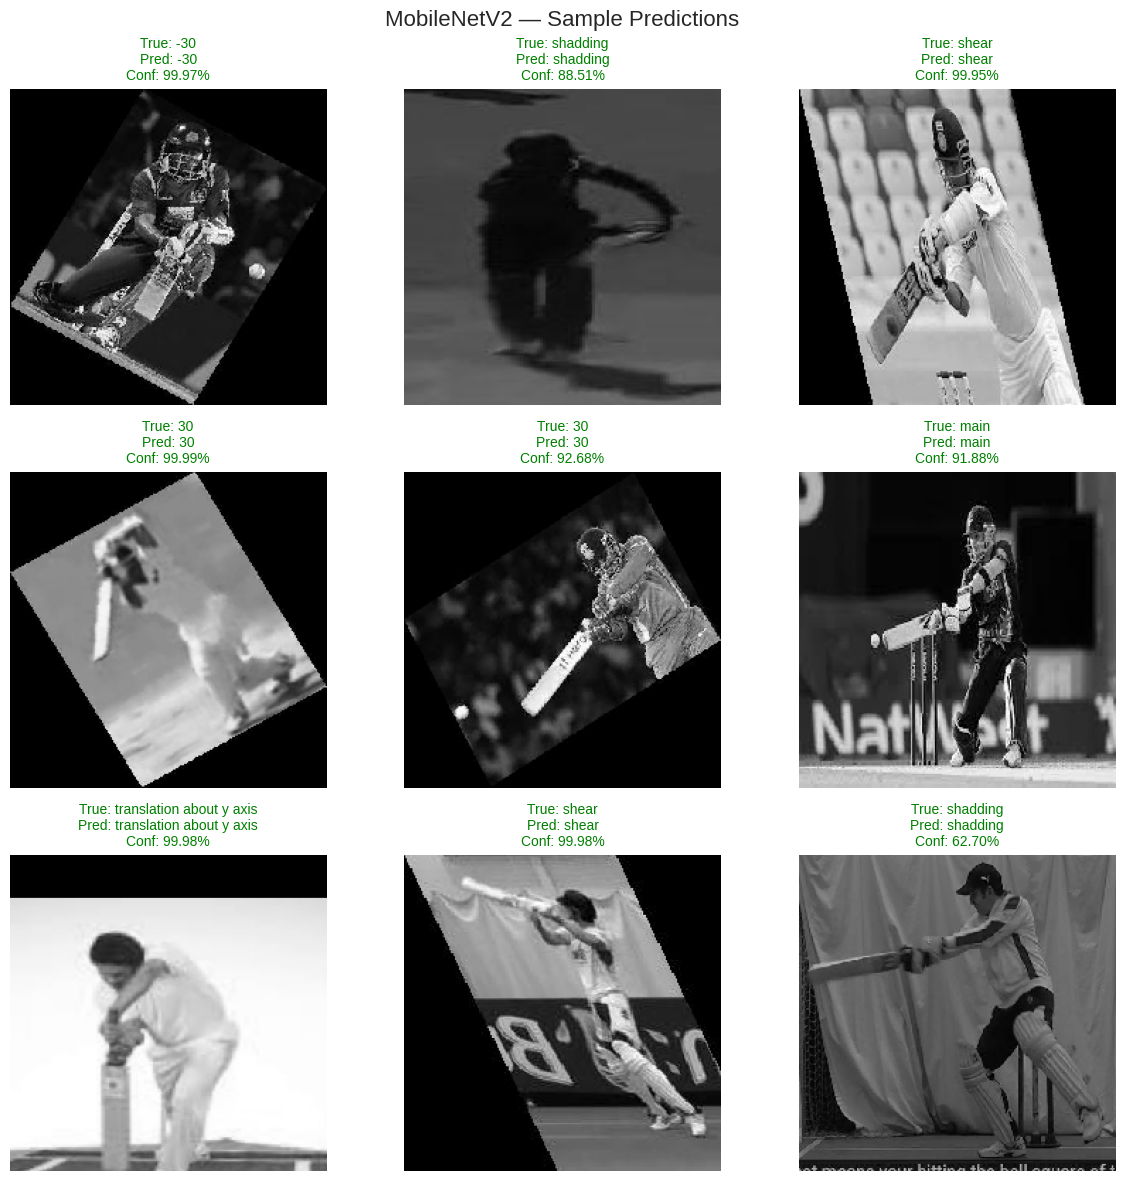

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img
import os

class_labels = list(test_data.class_indices.keys())

test_data.reset()
predictions = model.predict(test_data, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_data.classes

plt.figure(figsize=(12, 12))
for i, idx in enumerate(np.random.randint(0, len(test_data.filenames), 9)):
    img_path = os.path.join(test_data.directory, test_data.filenames[idx])
    img = load_img(img_path, target_size=(224, 224))
    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.axis('off')

    true_label = class_labels[true_classes[idx]]
    pred_label = class_labels[predicted_classes[idx]]
    confidence = np.max(predictions[idx]) * 100

    color = "green" if true_label == pred_label else "red"
    plt.title(
        f"Pred: {pred_label}\nTrue: {true_label}\nConf: {confidence:.1f}%",
        color=color, fontsize=10
    )

plt.suptitle("MobileNetV2 — Sample Predictions", fontsize=16)
plt.tight_layout()
plt.show()


# Confusion Matrix

119/119 ━━━━━━━━━━━━━━━━━━━━ 16s 137ms/step


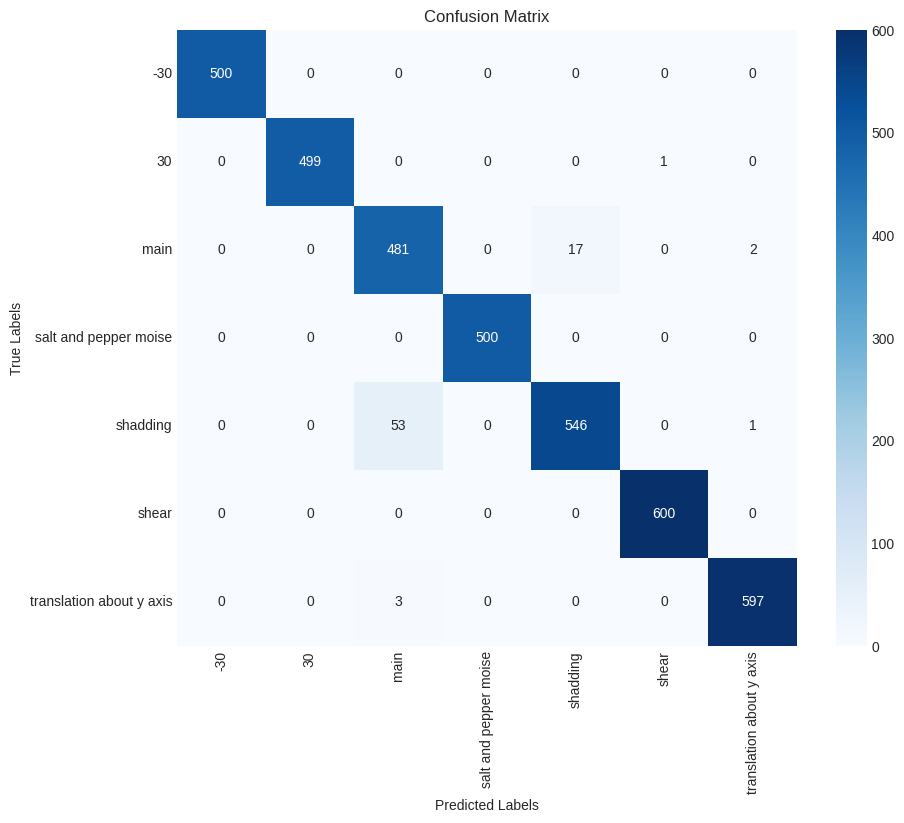

Classification Report:
                          precision    recall  f1-score   support

                     -30       1.00      1.00      1.00       500
                      30       1.00      1.00      1.00       500
                    main       0.90      0.96      0.93       500
   salt and pepper moise       1.00      1.00      1.00       500
                shadding       0.97      0.91      0.94       600
                   shear       1.00      1.00      1.00       600
translation about y axis       0.99      0.99      0.99       600

                accuracy                           0.98      3800
               macro avg       0.98      0.98      0.98      3800
            weighted avg       0.98      0.98      0.98      3800



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(test_data)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_data.classes


class_names = list(test_data.class_indices.keys())


cm = confusion_matrix(y_true, y_pred_classes)


plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()


print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_names))


# Performance Evaluation

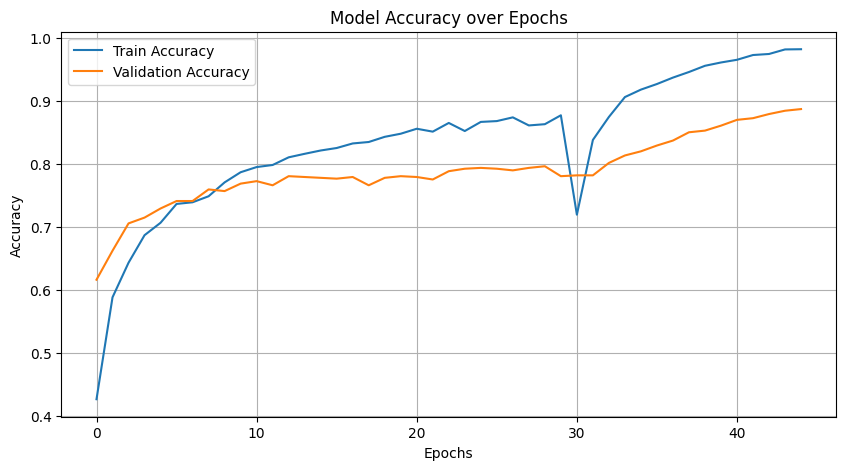

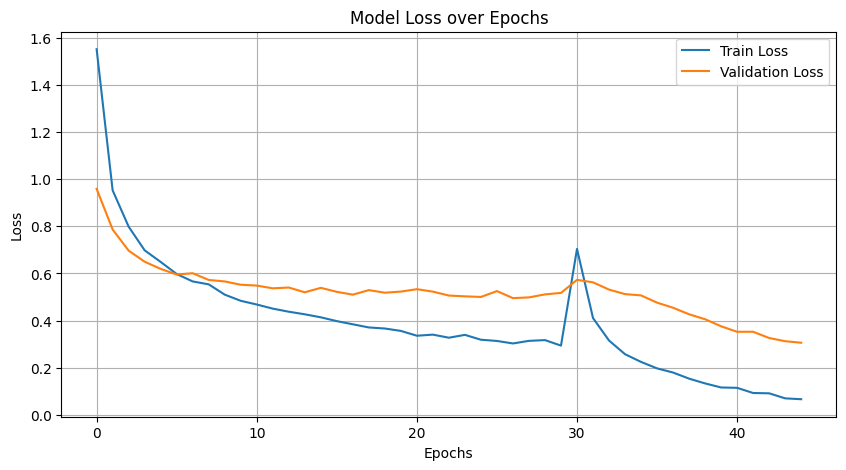

In [ ]:
import matplotlib.pyplot as plt
acc = history.history['accuracy'] + fine_tune_history.history['accuracy']
val_acc = history.history['val_accuracy'] + fine_tune_history.history['val_accuracy']

loss = history.history['loss'] + fine_tune_history.history['loss']
val_loss = history.history['val_loss'] + fine_tune_history.history['val_loss']

plt.figure(figsize=(10, 5))
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Model Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


# **Model 2 - Dense121**

# Import Libraries

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Build Model Dense121

In [ ]:
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(train_data.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# Model Compile

In [ ]:
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train Model

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    verbose=1
)


Epoch 1/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 62s 364ms/step - accuracy: 0.2340 - loss: 2.2275 - val_accuracy: 0.5895 - val_loss: 1.0211
Epoch 2/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 10s 102ms/step - accuracy: 0.5127 - loss: 1.2434 - val_accuracy: 0.6671 - val_loss: 0.8018
Epoch 3/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 10s 102ms/step - accuracy: 0.6047 - loss: 0.9462 - val_accuracy: 0.6776 - val_loss: 0.7067
Epoch 4/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - accuracy: 0.6498 - loss: 0.8142 - val_accuracy: 0.7105 - val_loss: 0.6571
Epoch 5/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 10s 100ms/step - accuracy: 0.6919 - loss: 0.7199 - val_accuracy: 0.7053 - val_loss: 0.6251
Epoch 6/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 10s 102ms/step - accuracy: 0.6948 - loss: 0.7149 - val_accuracy: 0.7421 - val_loss: 0.6012
Epoch 7/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 10s 100ms/step - accuracy: 0.7060 - loss: 0.6676 - val_accuracy: 0.7421 - val_loss: 0.5751
Epoch 8/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 10s 102ms/step - accuracy: 0.7110 - loss: 0.6395 - val_accura

In [ ]:
base_model.trainable = True
for layer in base_model.layers[:-40]:
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

fine_tune_history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    verbose=1
)

Epoch 1/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 80s 331ms/step - accuracy: 0.7611 - loss: 0.5717 - val_accuracy: 0.7697 - val_loss: 0.4966
Epoch 2/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step - accuracy: 0.7594 - loss: 0.5265 - val_accuracy: 0.7645 - val_loss: 0.4910
Epoch 3/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step - accuracy: 0.7769 - loss: 0.4842 - val_accuracy: 0.7724 - val_loss: 0.4804
Epoch 4/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - accuracy: 0.8061 - loss: 0.4483 - val_accuracy: 0.7763 - val_loss: 0.4657
Epoch 5/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 10s 104ms/step - accuracy: 0.7883 - loss: 0.4758 - val_accuracy: 0.7855 - val_loss: 0.4530
Epoch 6/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 10s 106ms/step - accuracy: 0.8189 - loss: 0.4207 - val_accuracy: 0.7947 - val_loss: 0.4390
Epoch 7/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - accuracy: 0.8184 - loss: 0.4182 - val_accuracy: 0.7961 - val_loss: 0.4300
Epoch 8/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 10s 110ms/step - accuracy: 0.8113 - loss: 0.4274 - val_accu

## Model Evaluate

In [ ]:
train_acc = fine_tune_history.history['accuracy'][-1]
val_acc = fine_tune_history.history['val_accuracy'][-1]
test_loss, test_acc = model.evaluate(test_data)

print(f"\n Final Training Accuracy: {train_acc*100:.2f}%")
print(f"Final Validation Accuracy: {val_acc*100:.2f}%")
print(f" Final Test Accuracy: {test_acc*100:.2f}%")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


12/12 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.9535 - loss: 0.1355

 Final Training Accuracy: 97.96%
Final Validation Accuracy: 92.11%
 Final Test Accuracy: 93.95%


# Visualize Some Predictions

119/119 ━━━━━━━━━━━━━━━━━━━━ 16s 137ms/step


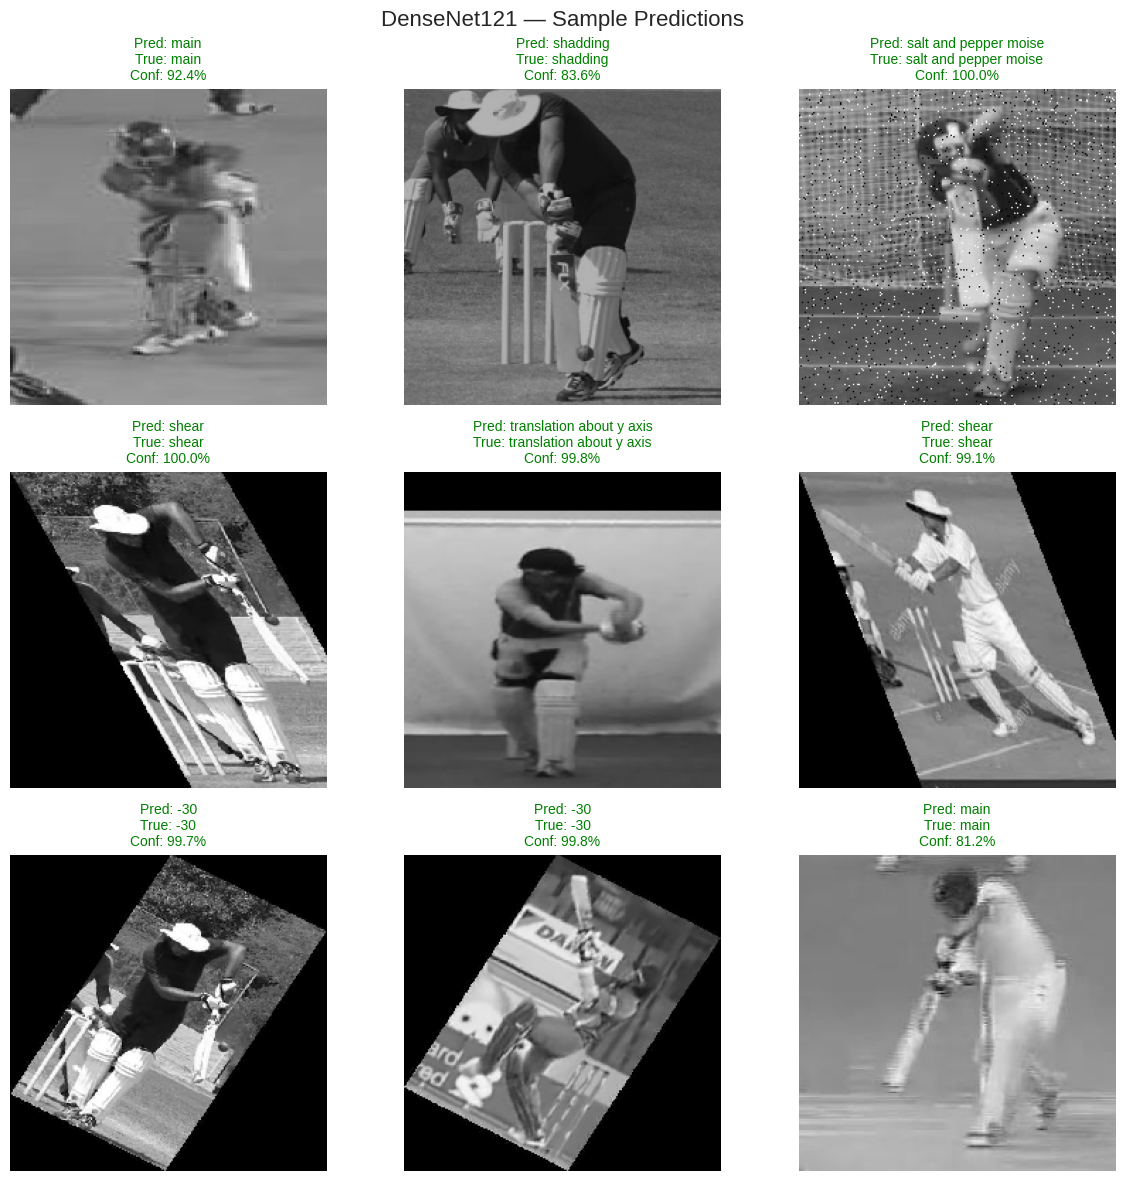

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img
import os

class_labels = list(test_data.class_indices.keys())

test_data.reset()
predictions = model.predict(test_data, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_data.classes

plt.figure(figsize=(12, 12))
for i, idx in enumerate(np.random.randint(0, len(test_data.filenames), 9)):
    img_path = os.path.join(test_data.directory, test_data.filenames[idx])
    img = load_img(img_path, target_size=(224, 224))
    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.axis('off')

    true_label = class_labels[true_classes[idx]]
    pred_label = class_labels[predicted_classes[idx]]
    confidence = np.max(predictions[idx]) * 100

    color = "green" if true_label == pred_label else "red"
    plt.title(
        f"Pred: {pred_label}\nTrue: {true_label}\nConf: {confidence:.1f}%",
        color=color, fontsize=10
    )

plt.suptitle("DenseNet121 — Sample Predictions", fontsize=16)
plt.tight_layout()
plt.show()


# Performance Evaluation

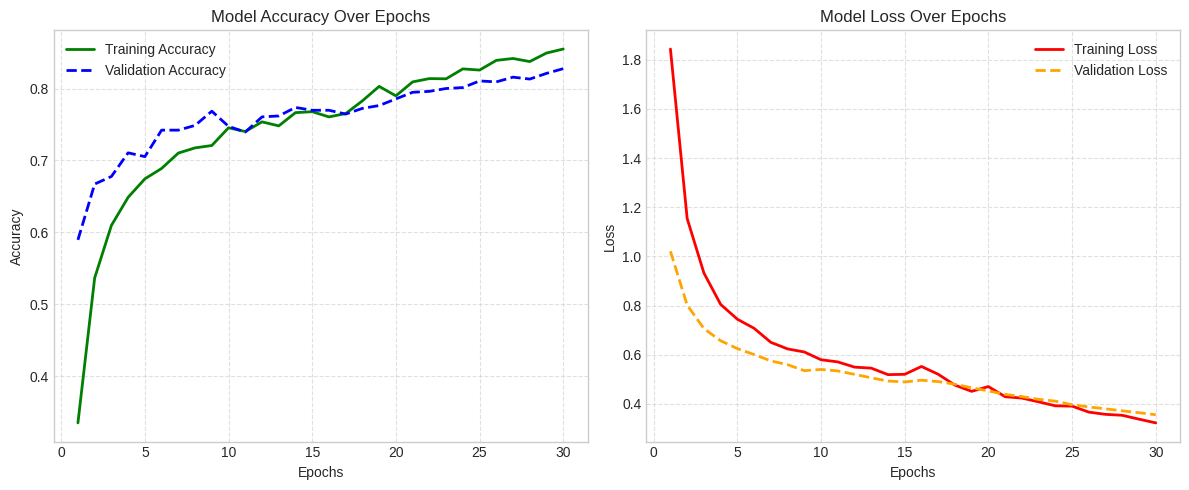

In [ ]:
import matplotlib.pyplot as plt
acc = history.history['accuracy'] + fine_tune_history.history['accuracy']
val_acc = history.history['val_accuracy'] + fine_tune_history.history['val_accuracy']
loss = history.history['loss'] + fine_tune_history.history['loss']
val_loss = history.history['val_loss'] + fine_tune_history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs, acc, label='Training Accuracy', color='green', linewidth=2)
plt.plot(epochs, val_acc, label='Validation Accuracy', color='blue', linestyle='--', linewidth=2)
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1,2,2)
plt.plot(epochs, loss, label='Training Loss', color='red', linewidth=2)
plt.plot(epochs, val_loss, label='Validation Loss', color='orange', linestyle='--', linewidth=2)
plt.title('Model Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()






# **Model 3 - InceptionResNetV2**

# Import Libraries

In [ ]:
from tensorflow.keras.applications import InceptionResNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam


# Build Model InceptionResNetV2

In [ ]:
base_model = InceptionResNetV2(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)

base_model.trainable = False

219055592/219055592 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step


# Compile Model

In [ ]:
from tensorflow.keras.applications import InceptionResNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

base_model = InceptionResNetV2(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
output = Dense(train_data.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(0.0008),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_203 (Conv2D) │ (None, 111, 111,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 111, 111,  │         96 │ conv2d_203[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_203      │ (None, 111, 111,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_204 (Conv2D) │ (None, 109, 109,  │      9,216 │ activation_203[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │         96 │ conv2d_204[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_204      │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_205 (Conv2D) │ (None, 109, 109,  │     18,432 │ activation_204[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │        192 │ conv2d_205[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_205      │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 54, 54,    │          0 │ activation_205[0… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_206 (Conv2D) │ (None, 54, 54,    │      5,120 │ max_pooling2d_4[… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 54, 54,    │        240 │ conv2d_206[0][0]  │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_206      │ (None, 54, 54,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_207 (Conv2D) │ (None, 52, 52,    │    138,240 │ activation_206[0… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 52, 52,    │        576 │ conv2d_207[0][0]  │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_207      │ (None, 52, 52,    │          0 │ batch_normalizat

 Total params: 54,349,028 (207.33 MB)

 Trainable params: 9,220 (36.02 KB)

 Non-trainable params: 54,339,808 (207.29 MB)

# Train Model

In [ ]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    verbose=1
)

Epoch 1/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 114s 984ms/step - accuracy: 0.2841 - loss: 2.2332 - val_accuracy: 0.4930 - val_loss: 1.2813
Epoch 2/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 46s 552ms/step - accuracy: 0.5010 - loss: 1.3973 - val_accuracy: 0.5842 - val_loss: 1.1012
Epoch 3/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 44s 528ms/step - accuracy: 0.5625 - loss: 1.2438 - val_accuracy: 0.5982 - val_loss: 1.0767
Epoch 4/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 43s 509ms/step - accuracy: 0.5563 - loss: 1.2548 - val_accuracy: 0.6351 - val_loss: 1.0181
Epoch 5/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 43s 517ms/step - accuracy: 0.5746 - loss: 1.1303 - val_accuracy: 0.6596 - val_loss: 0.9559
Epoch 6/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 47s 554ms/step - accuracy: 0.6009 - loss: 1.0709 - val_accuracy: 0.6807 - val_loss: 0.8997
Epoch 7/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 43s 514ms/step - accuracy: 0.6092 - loss: 1.0490 - val_accuracy: 0.6614 - val_loss: 0.9192
Epoch 8/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 44s 525ms/step - accuracy: 0.6362 - loss: 0.9958 - val_acc

In [ ]:
for layer in base_model.layers[-150:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

fine_tune_history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    verbose=1
)


Epoch 1/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 0.5748 - loss: 1.1766 - val_accuracy: 0.6860 - val_loss: 0.8120
Epoch 2/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 46s 543ms/step - accuracy: 0.6603 - loss: 0.9300 - val_accuracy: 0.7228 - val_loss: 0.7939
Epoch 3/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 45s 534ms/step - accuracy: 0.6830 - loss: 0.8832 - val_accuracy: 0.7509 - val_loss: 0.7569
Epoch 4/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 45s 536ms/step - accuracy: 0.7179 - loss: 0.7373 - val_accuracy: 0.7632 - val_loss: 0.6653
Epoch 5/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 45s 532ms/step - accuracy: 0.7401 - loss: 0.7030 - val_accuracy: 0.7702 - val_loss: 0.6558
Epoch 6/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 45s 539ms/step - accuracy: 0.7407 - loss: 0.6908 - val_accuracy: 0.8000 - val_loss: 0.5740
Epoch 7/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 45s 532ms/step - accuracy: 0.7821 - loss: 0.6214 - val_accuracy: 0.7860 - val_loss: 0.5756
Epoch 8/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 45s 530ms/step - accuracy: 0.8030 - loss: 0.5576 - val_accura

# Model Evaluate

In [ ]:
train_loss, train_acc = model.evaluate(train_gen)
print("Train Accuracy:", round(train_acc * 100, 2), "%")

val_loss, val_acc = model.evaluate(val_gen)
print("Validation Accuracy:", round(val_acc * 100, 2), "%")

test_loss, test_acc = model.evaluate(test_gen)
print("Test Accuracy:", round(test_acc * 100, 2), "%")


84/84 ━━━━━━━━━━━━━━━━━━━━ 37s 431ms/step - accuracy: 0.9642 - loss: 0.1322
Train Accuracy: 96.09 %
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 447ms/step - accuracy: 0.8899 - loss: 0.3224
Validation Accuracy: 89.12 %
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 149ms/step - accuracy: 0.8756 - loss: 0.3406
Test Accuracy: 89.12 %


# **Image Prediction**

In [ ]:
import os
import shutil
import zipfile
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.utils import load_img, img_to_array
from google.colab import files

# **Dataset Upload**

In [ ]:
print(" Please upload your cricket dataset zip file (e.g. cricket.zip)")
uploaded = files.upload()
zip_filename = list(uploaded.keys())[0]

extract_path = "./cricket_dataset"
flat_dataset_path = "./flattened_dataset"


 Please upload your cricket dataset zip file (e.g. cricket.zip)


Saving cricket-LAPTOP-NPIO3V9J.zip to cricket-LAPTOP-NPIO3V9J.zip


# **Dataset Extract**

In [ ]:
if os.path.exists(extract_path):
    shutil.rmtree(extract_path)
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print(" Dataset extracted successfully.")


 Dataset extracted successfully.


In [ ]:
def get_class_folders(base_dir):
    """Return list of leaf folders that contain image files."""
    class_dirs = []
    for root, dirs, files in os.walk(base_dir):
        image_files = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        if image_files and not dirs:  # leaf directory with images
            class_dirs.append(root)
    return class_dirs

class_folders = get_class_folders(extract_path)
print(f" Found {len(class_folders)} class folders.")

 Found 38 class folders.


In [ ]:
if os.path.exists(flat_dataset_path):
    shutil.rmtree(flat_dataset_path)
os.makedirs(flat_dataset_path, exist_ok=True)

for folder in class_folders:
    class_name = os.path.basename(folder)
    dest_class_dir = os.path.join(flat_dataset_path, class_name)
    os.makedirs(dest_class_dir, exist_ok=True)
    for file in os.listdir(folder):
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            src = os.path.join(folder, file)
            dst = os.path.join(dest_class_dir, file)
            shutil.copy2(src, dst)

print(f" Flattened dataset ready at: {flat_dataset_path}")

 Flattened dataset ready at: ./flattened_dataset


# **Image Generator**

In [ ]:
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = datagen.flow_from_directory(
    flat_dataset_path,
    target_size=(224, 224),
    batch_size=32,
    subset='training'
)

val_gen = datagen.flow_from_directory(
    flat_dataset_path,
    target_size=(224, 224),
    batch_size=32,
    subset='validation'
)

class_labels = list(train_gen.class_indices.keys())
print("\n Classes detected:", class_labels)
print(f" Total training images: {train_gen.samples + val_gen.samples}")


Found 3040 images belonging to 6 classes.
Found 760 images belonging to 6 classes.

 Classes detected: ['Cover Drive', 'Cut Shot', 'Leg Shot', 'Pull Shot', 'Scoop Shot', 'Straight Drive']
 Total training images: 3800


# **Train MobileNetV2 Model**

In [ ]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128, activation='relu')(x)
output = Dense(len(class_labels), activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)
for layer in base_model.layers:
    layer.trainable = False

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("\n🚀 Starting model training...\n")
model.fit(train_gen, validation_data=val_gen, epochs=5)

model.save("cricket_shot_model.h5")
print("\n Model saved as cricket_shot_model.h5")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

🚀 Starting model training...

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


95/95 ━━━━━━━━━━━━━━━━━━━━ 43s 257ms/step - accuracy: 0.4204 - loss: 1.5473 - val_accuracy: 0.5868 - val_loss: 1.1901
Epoch 2/5
95/95 ━━━━━━━━━━━━━━━━━━━━ 8s 89ms/step - accuracy: 0.7532 - loss: 0.6914 - val_accuracy: 0.6237 - val_loss: 0.9909
Epoch 3/5
95/95 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - accuracy: 0.8299 - loss: 0.4833 - val_accuracy: 0.6579 - val_loss: 0.9545
Epoch 4/5
95/95 ━━━━━━━━━━━━━━━━━━━━ 11s 111ms/step - accuracy: 0.8826 - loss: 0.3650 - val_accuracy: 0.6303 - val_loss: 0.9861
Epoch 5/5
95/95 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - accuracy: 0.9269 - loss: 0.2666 - val_accuracy: 0.6513 - val_loss: 0.9956



 Model saved as cricket_shot_model.h5


# **Upload a Test Image to Predict**

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.models import load_model
import numpy as np
from google.colab import files

print("\n📸 Upload a test image to predict:")
uploaded_img = files.upload()
test_image = list(uploaded_img.keys())[0]

def predict_image(img_path, model_path="cricket_shot_model.h5", class_labels=None):

    model = load_model(model_path)


    img = load_img(img_path, target_size=(224, 224))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)


    preds = model.predict(img_array)
    predicted_class = class_labels[np.argmax(preds)]
    confidence = np.max(preds)

    print(f"\n Predicted Class: {predicted_class} ({confidence*100:.2f}% confidence)")


    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(load_img(img_path))
    ax.axis("off")
    plt.show()

predict_image(test_image, class_labels=class_labels)

# **Live Overall Model Performance**

In [2]:
import plotly.graph_objects as go
models = ['VGG19', 'MobileNetV2', 'Dense121', 'InceptionResNetV2']

train_acc = [96.29, 99.44, 97.96, 96.09]
val_acc   = [96.36, 92.11, 92.11, 89.12]
test_acc  = [95.25, 97.97, 93.95, 89.12]

avg_acc = [(train_acc[i] + val_acc[i] + test_acc[i]) / 3 for i in range(len(models))]

best_model_index = avg_acc.index(max(avg_acc))
best_model_name  = models[best_model_index]
best_model_score = avg_acc[best_model_index]

colors = ['#3498DB', '#9B59B6', '#2ECC71', '#F1C40F']
colors[best_model_index] = '#FF5733'

frames = []
for i in range(1, 101):
    scale = i / 100
    annotations = []

    if i == 100:
        annotations = [
            dict(
                x=0.5,
                y=-0.25,
                xref='paper',
                yref='paper',
                text=(
                    f"Best Model: <span style='color:#FF5733'><b>{best_model_name}</b></span> "
                    f"with Overall Accuracy: <span style='color:#1F618D'><b>{best_model_score:.2f}%</b></span>"
                ),
                showarrow=False,
                font=dict(size=16)
            )
        ]

    frames.append(go.Frame(
        data=[
            go.Bar(y=models, x=[v * scale for v in train_acc], name='Train',
                   marker_color=colors, orientation='h',
                   text=[f"{v:.2f}%" if scale == 1 else "" for v in train_acc],
                   textposition='inside'),

            go.Bar(y=models, x=[v * scale for v in val_acc], name='Validation',
                   marker_color=colors, orientation='h',
                   text=[f"{v:.2f}%" if scale == 1 else "" for v in val_acc],
                   textposition='inside'),

            go.Bar(y=models, x=[v * scale for v in test_acc], name='Test',
                   marker_color=colors, orientation='h',
                   text=[f"{v:.2f}%" if scale == 1 else "" for v in test_acc],
                   textposition='inside')
        ],
        layout=go.Layout(annotations=annotations)
    ))

fig = go.Figure(
    data=[
        go.Bar(y=models, x=[0]*4, name="Train", marker_color=colors, orientation='h'),
        go.Bar(y=models, x=[0]*4, name="Validation", marker_color=colors, orientation='h'),
        go.Bar(y=models, x=[0]*4, name="Test", marker_color=colors, orientation='h'),
    ],
    frames=frames
)

fig.update_layout(
    title='Animated Overall Model Performance (Train / Val / Test)',
    title_font=dict(size=22, family='Arial Black'),
    xaxis=dict(title='Accuracy (%)', range=[0, 100], showgrid=True, gridcolor='lightgray'),
    yaxis=dict(title='Models'),
    barmode='group',
    bargap=0.25,
    plot_bgcolor='white',
    paper_bgcolor='white',
    legend=dict(title='Metrics', orientation='h', y=-0.2),
    updatemenus=[{
        "type": "buttons",
        "buttons": [{
            "label": "▶ Play Animation",
            "method": "animate",
            "args": [None, {"frame": {"duration": 30, "redraw": True},
                            "transition": {"duration": 0}}]
        }]
    }]
)

fig.show()
